# Exploratory Data Analysis - Heart Disease

This notebook explores the dataset before applying IQR and Z-Score outlier detection.

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from config.config import Data_Path

In [4]:
df = pd.read_csv(Data_Path)
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## 1. Basic Information

In [5]:
print('Shape:', df.shape)
print('\nData types and missing values:')
df.info()

Shape: (10000, 21)

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours         

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    'Missing': missing,
    'Percentage': missing_percent
})
missing_table

,Missing,Percentage
Alcohol Consumption,2586,25.86
Cholesterol Level,30,0.30
Diabetes,30,0.30
Sugar Consumption,30,0.30
Age,29,0.29
CRP Level,26,0.26
Triglyceride Level,26,0.26
High Blood Pressure,26,0.26
High LDL Cholesterol,26,0.26
Low HDL Cholesterol,25,0.25


## 2. Numerical Features

In [7]:
numeric_columns = df.select_dtypes(include='number').columns
numeric_columns

Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='object')

In [8]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9971.0,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000
Blood Pressure,9981.0,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000
Cholesterol Level,9970.0,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000
BMI,9978.0,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954
Sleep Hours,9975.0,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952
Triglyceride Level,9974.0,250.734409,87.067226,100.000000,176.000000,250.000000,326.000000,400.000000
Fasting Blood Sugar,9978.0,120.142213,23.584011,80.000000,99.000000,120.000000,141.000000,160.000000
CRP Level,9974.0,7.472201,4.340248,0.003647,3.674126,7.472164,11.255592,14.997087
Homocysteine Level,9980.0,12.456271,4.323426,5.000236,8.723334,12.409395,16.140564,19.999037


In [9]:
df[numeric_columns].nunique().sort_values()

Blood Pressure           61
Age                      63
Fasting Blood Sugar      81
Cholesterol Level       151
Triglyceride Level      301
CRP Level              9974
Sleep Hours            9975
BMI                    9978
Homocysteine Level     9980
dtype: int64

## 3. Target Distribution

In [10]:
df['Heart Disease Status'].value_counts()

Heart Disease Status
No     8000
Yes    2000
Name: count, dtype: int64

## 4. Distribution and Skewness

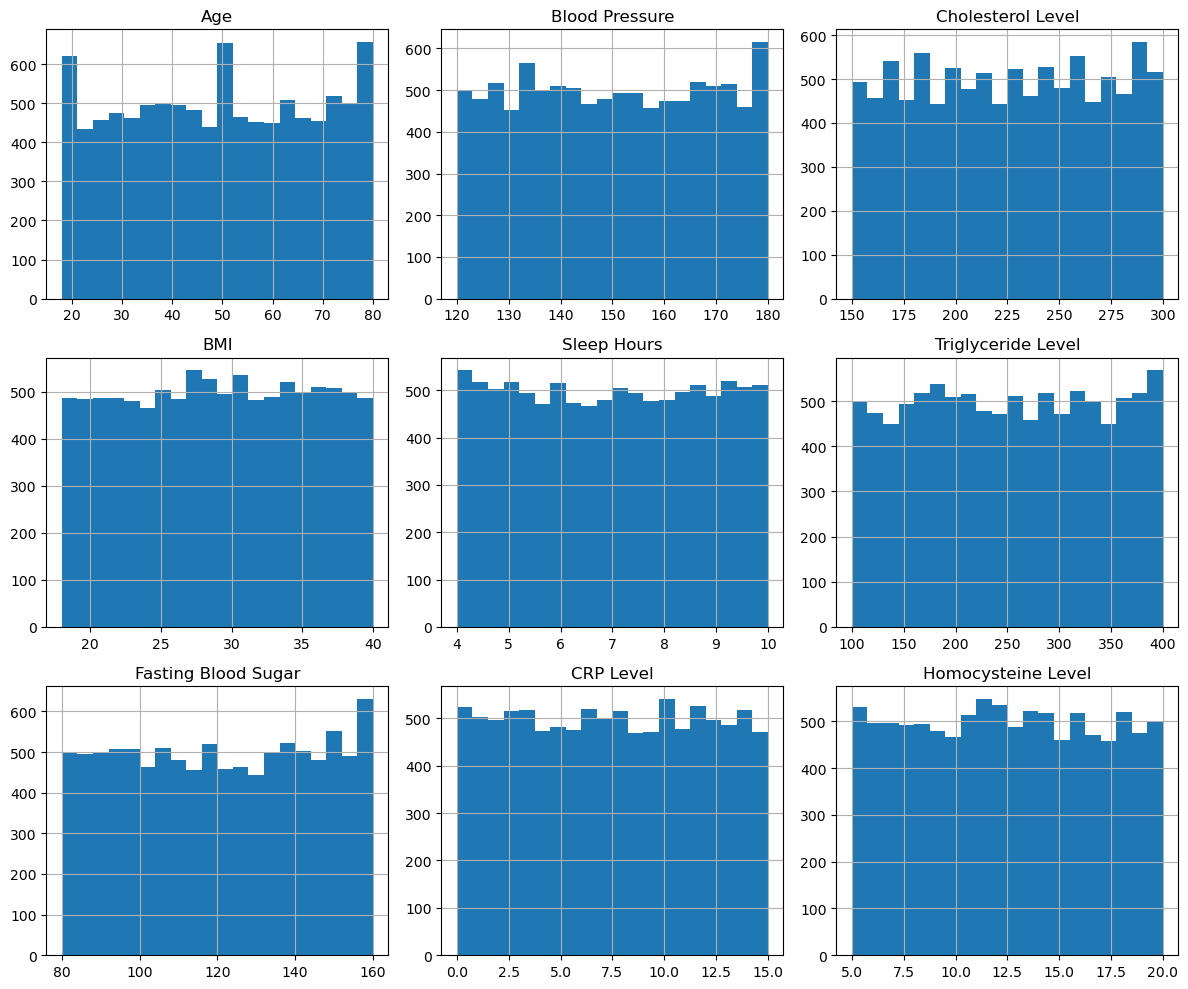

In [11]:
df[numeric_columns].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

In [12]:
df[numeric_columns].skew().sort_values()

BMI                   -0.021342
Fasting Blood Sugar   -0.008915
Cholesterol Level     -0.007120
Age                   -0.006789
CRP Level             -0.004069
Sleep Hours            0.000172
Triglyceride Level     0.006142
Homocysteine Level     0.007886
Blood Pressure         0.013907
dtype: float64

## 5. IQR Outlier Detection

We use the standard 1.5 × IQR rule. Extreme fences are not used.

In [13]:
iqr_results = []

for column in numeric_columns:
    data = df[column].dropna()
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((data < lower) | (data > upper)).sum()

    iqr_results.append([column, q1, q3, iqr, lower, upper, count])

iqr_table = pd.DataFrame(
    iqr_results,
    columns=['Feature', 'Q1', 'Q3', 'IQR', 'Lower Fence', 'Upper Fence', 'Outlier Count']
)

iqr_table

,Feature,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
0,Age,34.000000,65.000000,31.000000,-12.500000,111.500000,0
1,Blood Pressure,134.000000,165.000000,31.000000,87.500000,211.500000,0
2,Cholesterol Level,187.000000,263.000000,76.000000,73.000000,377.000000,0
3,BMI,23.658075,34.520015,10.861940,7.365165,50.812925,0
4,Sleep Hours,5.449866,8.531577,3.081711,0.827300,13.154144,0
5,Triglyceride Level,176.000000,326.000000,150.000000,-49.000000,551.000000,0
6,Fasting Blood Sugar,99.000000,141.000000,42.000000,36.000000,204.000000,0
7,CRP Level,3.674126,11.255592,7.581466,-7.698072,22.627790,0
8,Homocysteine Level,8.723334,16.140564,7.417230,-2.402510,27.266408,0


## 6. Z-Score Outlier Detection

A value is treated as a potential outlier when |Z| > 3.

In [14]:
zscore_results = []

for column in numeric_columns:
    data = df[column].dropna()
    mean = data.mean()
    std = data.std()
    z = (data - mean) / std
    count = (z.abs() > 3).sum()
    zscore_results.append([column, mean, std, count])

zscore_table = pd.DataFrame(
    zscore_results,
    columns=['Feature', 'Mean', 'Std', 'Z-Score Outlier Count']
)

zscore_table

,Feature,Mean,Std,Z-Score Outlier Count
0,Age,49.296259,18.193970,0
1,Blood Pressure,149.757740,17.572969,0
2,Cholesterol Level,225.425577,43.575809,0
3,BMI,29.077269,6.307098,0
4,Sleep Hours,6.991329,1.753195,0
5,Triglyceride Level,250.734409,87.067226,0
6,Fasting Blood Sugar,120.142213,23.584011,0
7,CRP Level,7.472201,4.340248,0
8,Homocysteine Level,12.456271,4.323426,0


## 7. Comparison

In [15]:
comparison = iqr_table[['Feature', 'Outlier Count']].copy()
comparison = comparison.rename(columns={'Outlier Count': 'IQR Outliers'})
comparison['Z-Score Outliers'] = zscore_table['Z-Score Outlier Count'].values
comparison['Total Outliers'] = comparison['IQR Outliers'] + comparison['Z-Score Outliers']
comparison

,Feature,IQR Outliers,Z-Score Outliers,Total Outliers
0,Age,0,0,0
1,Blood Pressure,0,0,0
2,Cholesterol Level,0,0,0
3,BMI,0,0,0
4,Sleep Hours,0,0,0
5,Triglyceride Level,0,0,0
6,Fasting Blood Sugar,0,0,0
7,CRP Level,0,0,0
8,Homocysteine Level,0,0,0
